In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, silhouette_samples

# Clustering

In [56]:
df = pd.read_csv('../data/cleaned_data/eda_data.csv')

In [57]:
df.head()

,udi,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,...,rotational_speed_delta,rotational_speed_lag1,torque_roll_mean_5,torque_roll_std_5,torque_delta,torque_lag1,tool_wear_roll_mean_5,tool_wear_roll_std_5,tool_wear_delta,tool_wear_lag1
0,1,M,298.1,308.6,1551,42.8,0,0,0,0,...,0.0,1538.7761,42.800000,0.000000,0.0,39.98691,0.000000,0.000000,0.0,107.951
1,2,L,298.2,308.7,1408,46.3,3,0,0,0,...,-143.0,1551.0000,44.550000,2.474874,3.5,42.80000,1.500000,2.121320,3.0,0.000
2,3,L,298.1,308.5,1498,49.4,5,0,0,0,...,90.0,1408.0000,46.166667,3.302020,3.1,46.30000,2.666667,2.516611,2.0,3.000
3,4,L,298.2,308.6,1433,39.5,7,0,0,0,...,-65.0,1498.0000,44.500000,4.287190,-9.9,49.40000,3.750000,2.986079,2.0,5.000
4,5,L,298.2,308.7,1408,40.0,9,0,0,0,...,-25.0,1433.0000,43.600000,4.223150,0.5,39.50000,4.800000,3.492850,2.0,7.000


In [58]:
df.columns

Index(['udi', 'type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf',
       'hdf', 'pwf', 'osf', 'rnf', 'type_enc', 'temp_diff', 'power_W',
       'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload',
       'air_temperature_roll_mean_5', 'air_temperature_roll_std_5',
       'air_temperature_delta', 'air_temperature_lag1',
       'process_temperature_roll_mean_5', 'process_temperature_roll_std_5',
       'process_temperature_delta', 'process_temperature_lag1',
       'rotational_speed_roll_mean_5', 'rotational_speed_roll_std_5',
       'rotational_speed_delta', 'rotational_speed_lag1', 'torque_roll_mean_5',
       'torque_roll_std_5', 'torque_delta', 'torque_lag1',
       'tool_wear_roll_mean_5', 'tool_wear_roll_std_5', 'tool_wear_delta',
       'tool_wear_lag1'],
      dtype='object')

### Feature Selection

In [59]:
SENSOR_COLS = ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear']

In [60]:
X_raw = df[SENSOR_COLS].copy()

In [61]:
# Scaled Dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=SENSOR_COLS)

print("After scaling — mean:") # should be ~ 0
print(X_scaled_df.mean().round(6))
print("\nAfter scaling — std:") # should be ~ 1
print(X_scaled_df.std().round(4))

After scaling — mean:
air_temperature       -0.0
process_temperature   -0.0
rotational_speed      -0.0
torque                 0.0
tool_wear              0.0
dtype: float64

After scaling — std:
air_temperature        1.0001
process_temperature    1.0001
rotational_speed       1.0001
torque                 1.0001
tool_wear              1.0001
dtype: float64


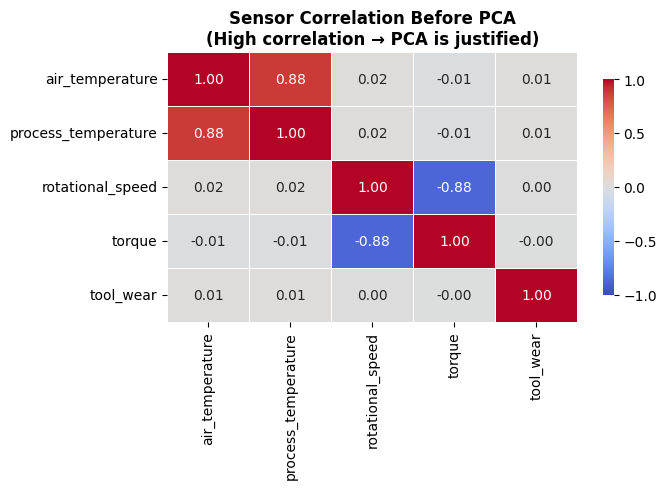

In [62]:
# Coorelation Check
fig, ax = plt.subplots(figsize=(7, 5))
corr = X_scaled_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Sensor Correlation Before PCA\n(High correlation → PCA is justified)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/pre_pca_correlation.png', bbox_inches='tight')
plt.show()

## PCA

In [63]:
pca_full = PCA(n_components=5, random_state=42)
X_pca = pca_full.fit_transform(X_scaled) 

In [64]:
evr   = pca_full.explained_variance_ratio_
cumev = np.cumsum(evr)

print("Explained Variance per Component:")
for i, (e, c) in enumerate(zip(evr, cumev), 1):
    bar = '█' * int(e * 50)
    print(f"  PC{i}: {e*100:5.2f}%  (cumulative: {c*100:5.2f}%)  {bar}")

Explained Variance per Component:
  PC1: 38.21%  (cumulative: 38.21%)  ███████████████████
  PC2: 36.82%  (cumulative: 75.03%)  ██████████████████
  PC3: 19.99%  (cumulative: 95.02%)  █████████
  PC4:  2.53%  (cumulative: 97.55%)  █
  PC5:  2.45%  (cumulative: 100.00%)  █


In [65]:
print("Total explained variance:", np.sum(pca_full.explained_variance_ratio_))

Total explained variance: 1.0


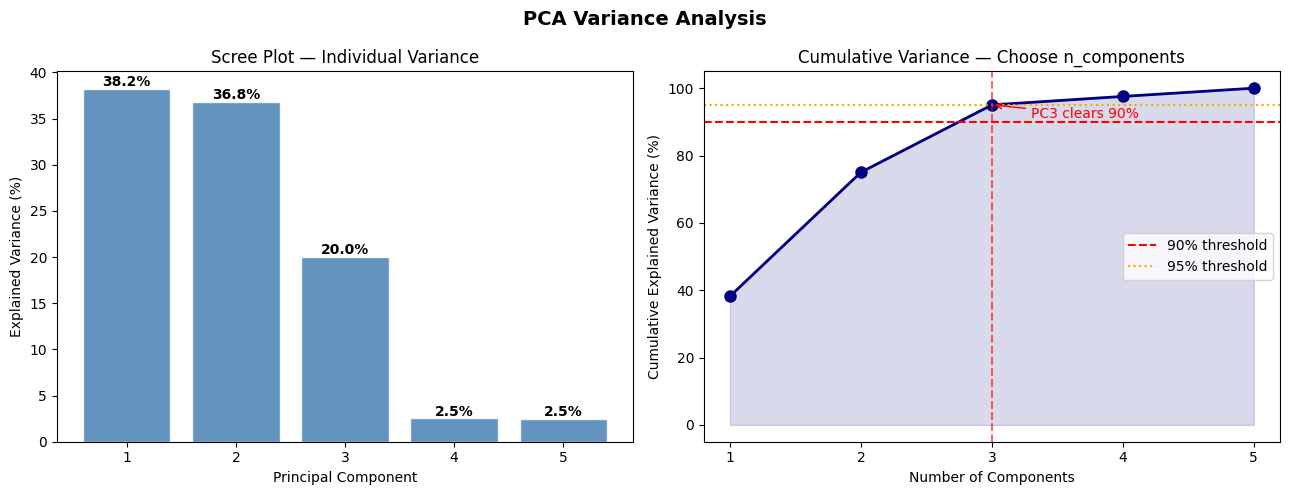


→  We select n_components = 3  (explains 95.0% of variance)


In [66]:
# ── Scree plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual explained variance
axes[0].bar(range(1, 6), evr * 100, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Variance')
axes[0].set_xticks(range(1, 6))
for i, v in enumerate(evr * 100):
    axes[0].text(i+1, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Cumulative explained variance
axes[1].plot(range(1, 6), cumev * 100, 'o-', color='navy',
             linewidth=2, markersize=8)
axes[1].fill_between(range(1, 6), cumev * 100, alpha=0.15, color='navy')
axes[1].axhline(90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].axhline(95, color='orange', linestyle=':', linewidth=1.5, label='95% threshold')

# Mark which n_components clears 90%
n90 = np.argmax(cumev >= 0.90) + 1
axes[1].axvline(n90, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
axes[1].annotate(f'PC{n90} clears 90%', xy=(n90, cumev[n90-1]*100),
                 xytext=(n90+0.3, cumev[n90-1]*100 - 4),
                 fontsize=10, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance — Choose n_components')
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.suptitle('PCA Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/pca_scree.png', bbox_inches='tight')
plt.show()

print(f"\n→  We select n_components = {n90}  (explains {cumev[n90-1]*100:.1f}% of variance)")

In [67]:
# ── Fit final PCA with chosen n_components ──────────────────────────────────
N_COMPONENTS = n90   # determined automatically above

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])

print(f"PCA output shape: {X_pca_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_ * 100}")

PCA output shape: (10000, 3)
Explained variance: [38.21480997 36.81704817 19.99152589]


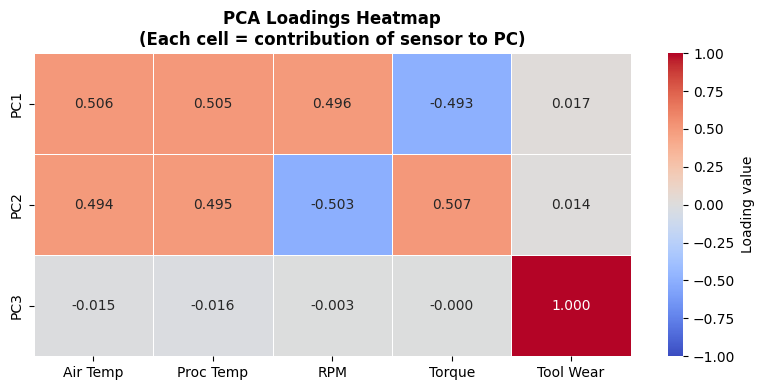


Interpretation:
  PC1 is most influenced by: Air Temp  (loading=0.506)
  PC2 is most influenced by: Torque  (loading=0.507)
  PC3 is most influenced by: Tool Wear  (loading=1.000)


In [68]:
# ── Loadings heatmap ────────────────────────────────────────────────────────
short_names = ['Air Temp', 'Proc Temp', 'RPM', 'Torque', 'Tool Wear']
loadings = pd.DataFrame(pca.components_,
                        columns=short_names,
                        index=[f'PC{i+1}' for i in range(N_COMPONENTS)])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Loading value'})
ax.set_title('PCA Loadings Heatmap\n(Each cell = contribution of sensor to PC)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/pca_loadings.png', bbox_inches='tight')
plt.show()

print("\nInterpretation:")
for i in range(N_COMPONENTS):
    top = loadings.iloc[i].abs().idxmax()
    print(f"  PC{i+1} is most influenced by: {top}  (loading={loadings.iloc[i][top]:.3f})")

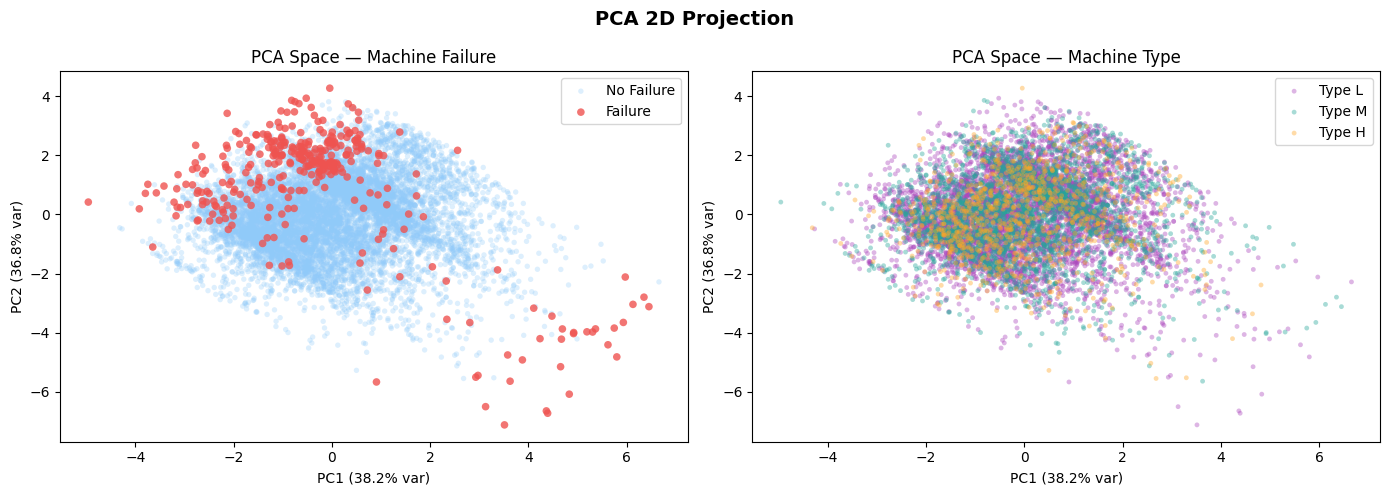

In [69]:
# ── 2D PCA scatter — coloured by Machine Failure ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

failure_col = df['machine_failure'].values
palette = {0: '#90CAF9', 1: '#EF5350'}

for fail_val, label, alpha in [(0, 'No Failure', 0.3), (1, 'Failure', 0.8)]:
    mask = failure_col == fail_val
    axes[0].scatter(X_pca_df.loc[mask, 'PC1'], X_pca_df.loc[mask, 'PC2'],
                    c=palette[fail_val], label=label,
                    s=15 if fail_val == 0 else 30,
                    alpha=alpha, edgecolors='none')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('PCA Space — Machine Failure')
axes[0].legend()

# Colour by Type
type_enc = df['type_enc'].values
type_map_inv = {0:'L', 1:'M', 2:'H'}
type_palette = {'L':'#AB47BC', 'M':'#26A69A', 'H':'#FFA726'}
for te, label in [(0,'L'),(1,'M'),(2,'H')]:
    mask = type_enc == te
    axes[1].scatter(X_pca_df.loc[mask,'PC1'], X_pca_df.loc[mask,'PC2'],
                    c=type_palette[label], label=f'Type {label}',
                    s=12, alpha=0.4, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('PCA Space — Machine Type')
axes[1].legend()

plt.suptitle('PCA 2D Projection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/pca_2d_scatter.png', bbox_inches='tight')
plt.show()

## KNN clustering

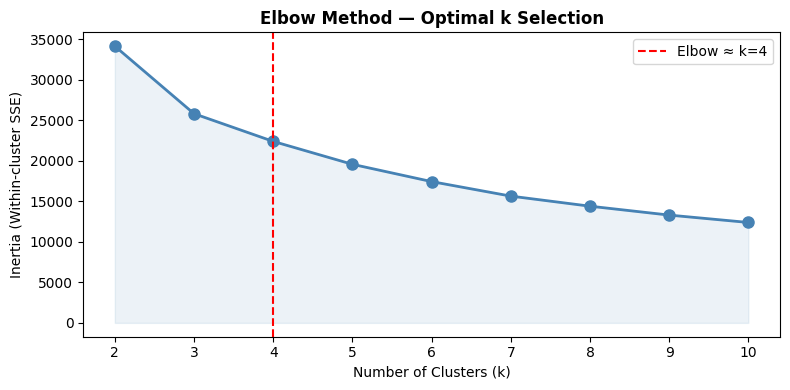

In [70]:
# ── Elbow method ────────────────────────────────────────────────────────────
inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.fill_between(K_range, inertias, alpha=0.1, color='steelblue')

# Annotate elbow heuristic
diffs  = np.diff(inertias)
diffs2 = np.diff(diffs)
elbow_k = K_range[np.argmax(np.abs(diffs2)) + 2]   # +2 because two diffs shrink array
ax.axvline(elbow_k, color='red', linestyle='--', linewidth=1.5,
           label=f'Elbow ≈ k={elbow_k}')

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
ax.set_title('Elbow Method — Optimal k Selection', fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig('../plots/elbow.png', bbox_inches='tight')
plt.show()

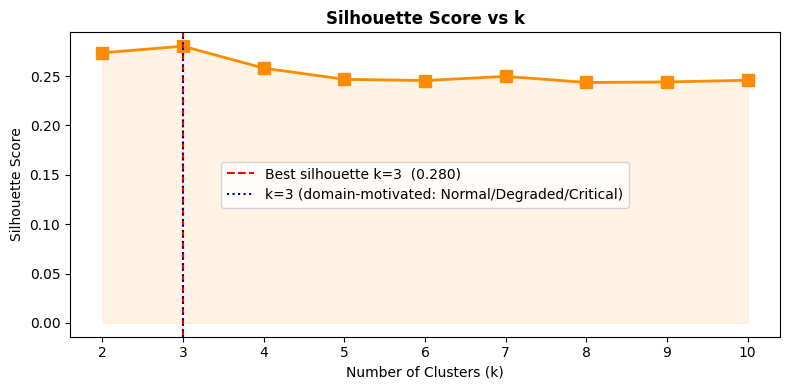

Best silhouette score → k=3  (0.2803)
We proceed with k=3 to align with the domain-driven Normal/Degraded/Critical schema.


In [72]:
# ── Silhouette scores ────────────────────────────────────────────────────────
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

best_k_sil = K_range[np.argmax(sil_scores)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, sil_scores, 's-', color='darkorange', linewidth=2, markersize=8)
ax.fill_between(K_range, sil_scores, alpha=0.1, color='darkorange')
ax.axvline(best_k_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Best silhouette k={best_k_sil}  ({max(sil_scores):.3f})')
ax.axvline(3, color='navy', linestyle=':', linewidth=1.5,
           label='k=3 (domain-motivated: Normal/Degraded/Critical)')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs k', fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig('../plots/silhouette_scores.png', bbox_inches='tight')
plt.show()

print(f"Best silhouette score → k={best_k_sil}  ({max(sil_scores):.4f})")
print("We proceed with k=3 to align with the domain-driven Normal/Degraded/Critical schema.")

In [74]:
# ── Fit final K-Means with k=3 ──────────────────────────────────────────────
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
cluster_labels_raw = kmeans.fit_predict(X_pca)

# ── Map raw cluster IDs → health regime labels ───────────────────────────────
# We identify which raw cluster has the highest mean failure rate
# and assign Critical → Degraded → Normal accordingly
cluster_fail_rate = {}
for c in range(K_FINAL):
    mask = cluster_labels_raw == c
    cluster_fail_rate[c] = df.loc[mask, 'machine_failure'].mean()

sorted_by_fail = sorted(cluster_fail_rate, key=cluster_fail_rate.get, reverse=True)
# sorted_by_fail[0] = highest failure rate → Critical
# sorted_by_fail[1] = middle → Degraded
# sorted_by_fail[2] = lowest → Normal

raw_to_regime = {
    sorted_by_fail[0]: 'Critical',
    sorted_by_fail[1]: 'Degraded',
    sorted_by_fail[2]: 'Normal',
}
print("Raw cluster → Health Regime mapping:")
for raw, regime in raw_to_regime.items():
    print(f"  Cluster {raw} → {regime}  (failure rate: {cluster_fail_rate[raw]*100:.2f}%)")

df['cluster_raw']    = cluster_labels_raw
df['health_regime']  = df['cluster_raw'].map(raw_to_regime)
X_pca_df['cluster_raw']   = cluster_labels_raw
X_pca_df['health_regime'] = df['health_regime'].values

Raw cluster → Health Regime mapping:
  Cluster 0 → Critical  (failure rate: 5.27%)
  Cluster 2 → Degraded  (failure rate: 2.20%)
  Cluster 1 → Normal  (failure rate: 2.18%)


In [75]:
# ── Cluster summary statistics ───────────────────────────────────────────────
print("=== Cluster Summary ===\n")
summary = df.groupby('health_regime').agg(
    Count=('machine_failure', 'count'),
    Failure_rate=('machine_failure', 'mean'),
    **{col.split('[')[0].strip(): (col, 'mean') for col in SENSOR_COLS}
).round(3)
print(summary.to_string())

=== Cluster Summary ===

               Count  Failure_rate  air_temperature  process_temperature  rotational_speed  torque  tool_wear
health_regime                                                                                                
Critical        3907         0.053          301.725               311.25          1469.108  43.704    110.429
Degraded        2094         0.022          300.120               310.10          1793.786  26.680    109.206
Normal          3999         0.022          298.264               308.74          1473.311  43.323    104.873


### Visualization

In [76]:
CLUSTER_COLORS = {'Normal': '#4CAF50', 'Degraded': '#FF9800', 'Critical': '#F44336'}

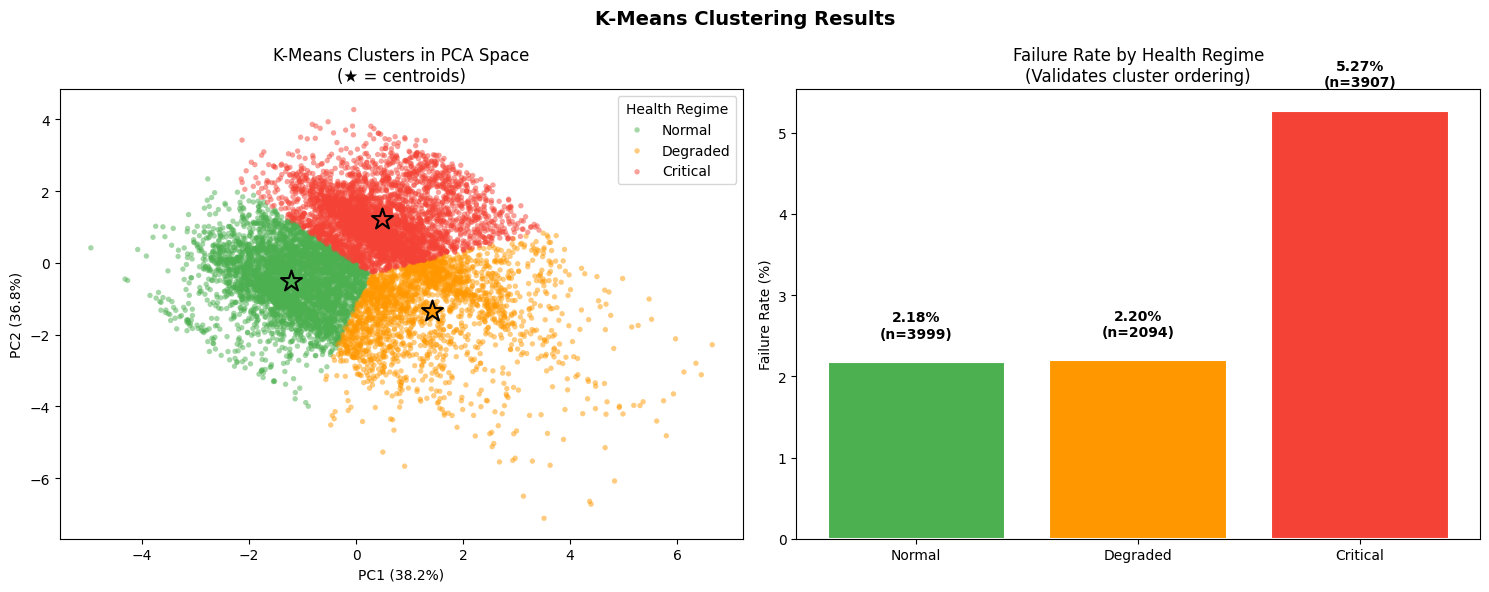

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 5a — Clusters in PC1/PC2 space
for regime, color in CLUSTER_COLORS.items():
    mask = X_pca_df['health_regime'] == regime
    axes[0].scatter(X_pca_df.loc[mask, 'PC1'],
                    X_pca_df.loc[mask, 'PC2'],
                    c=color, label=regime,
                    s=15, alpha=0.5, edgecolors='none')

# Plot centroids in PC space
centroids_pca = kmeans.cluster_centers_
centroid_regimes = [raw_to_regime[c] for c in range(K_FINAL)]
for i, regime in enumerate(centroid_regimes):
    axes[0].scatter(centroids_pca[i, 0], centroids_pca[i, 1],
                    c=CLUSTER_COLORS[regime], s=250, marker='*',
                    edgecolors='black', linewidth=1.5, zorder=5)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('K-Means Clusters in PCA Space\n(★ = centroids)')
axes[0].legend(title='Health Regime')

# 5b — Failure rate per cluster
regimes_order = ['Normal', 'Degraded', 'Critical']
fail_rates = [df[df['health_regime']==r]['machine_failure'].mean()*100
              for r in regimes_order]
counts = [df[df['health_regime']==r].shape[0] for r in regimes_order]

bars = axes[1].bar(regimes_order, fail_rates,
                   color=[CLUSTER_COLORS[r] for r in regimes_order],
                   edgecolor='white', linewidth=1.5)
for bar, rate, cnt in zip(bars, fail_rates, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{rate:.2f}%\n(n={cnt})',
                 ha='center', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_title('Failure Rate by Health Regime\n(Validates cluster ordering)')

plt.suptitle('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/cluster_pca_scatter.png', bbox_inches='tight')
plt.show()

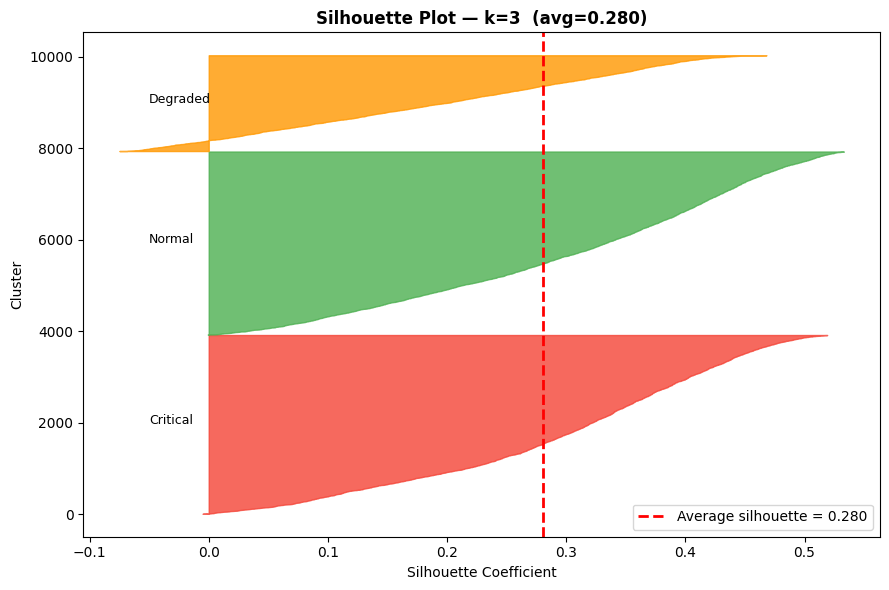

In [79]:
# ── Silhouette plot for k=3 ─────────────────────────────────────────────────
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(9, 6))

sil_vals = silhouette_samples(X_pca, cluster_labels_raw)
y_lower = 10

for c in range(K_FINAL):
    regime_name = raw_to_regime[c]
    c_sil = np.sort(sil_vals[cluster_labels_raw == c])
    size_c = c_sil.shape[0]
    y_upper = y_lower + size_c

    color = CLUSTER_COLORS[regime_name]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_c, regime_name, fontsize=9)
    y_lower = y_upper + 10

overall_sil = silhouette_score(X_pca, cluster_labels_raw)
ax.axvline(overall_sil, color='red', linestyle='--', linewidth=2,
           label=f'Average silhouette = {overall_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — k=3  (avg={overall_sil:.3f})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/silhouette_plot.png', bbox_inches='tight')
plt.show()

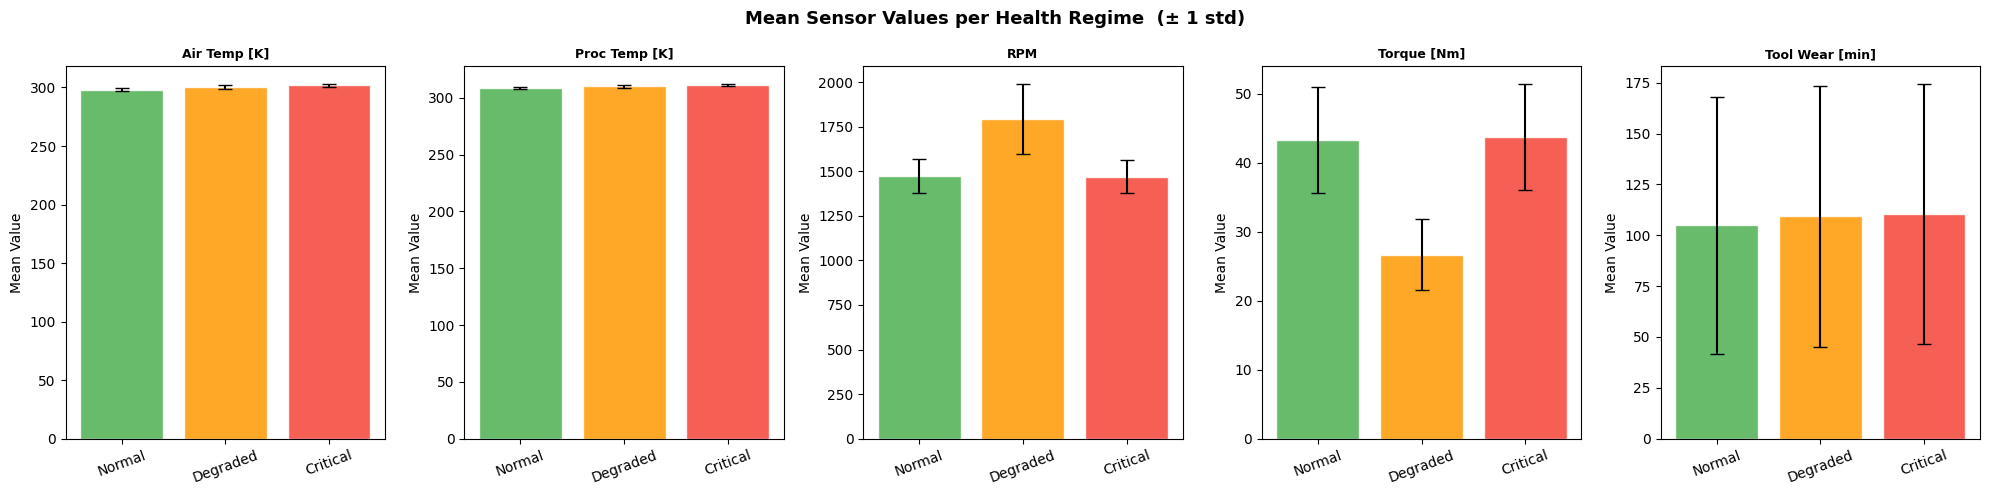

In [80]:
# ── Sensor profiles per cluster (radar / bar) ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

short_names = ['Air Temp [K]', 'Proc Temp [K]', 'RPM', 'Torque [Nm]', 'Tool Wear [min]']
regimes_order = ['Normal', 'Degraded', 'Critical']

for i, (col, sname) in enumerate(zip(SENSOR_COLS, short_names)):
    ax = axes[i]
    means = [df[df['health_regime']==r][col].mean() for r in regimes_order]
    stds  = [df[df['health_regime']==r][col].std()  for r in regimes_order]

    bars = ax.bar(regimes_order, means,
                  yerr=stds, capsize=5,
                  color=[CLUSTER_COLORS[r] for r in regimes_order],
                  edgecolor='white', alpha=0.85)
    ax.set_title(sname, fontsize=9, fontweight='bold')
    ax.set_ylabel('Mean Value')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Mean Sensor Values per Health Regime  (± 1 std)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/cluster_sensor_profiles.png', bbox_inches='tight')
plt.show()

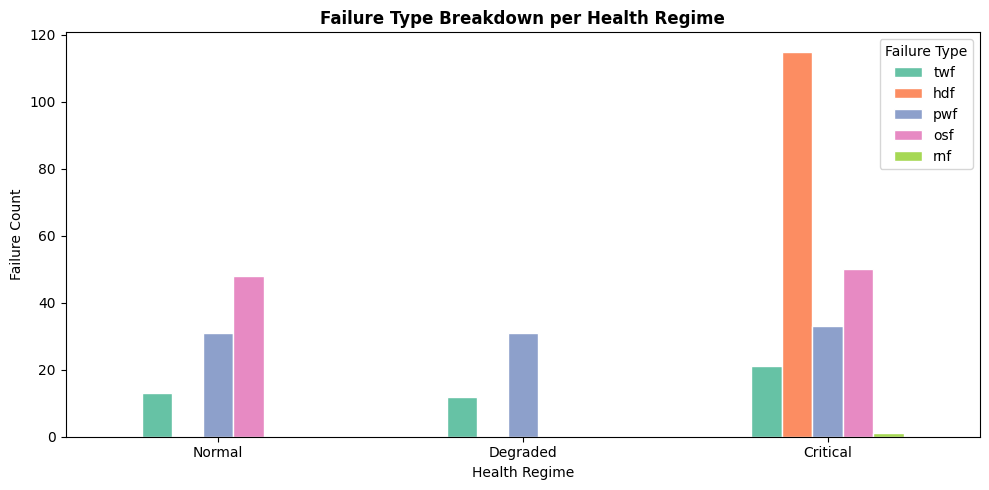

In [81]:
# ── Failure type distribution per health regime ─────────────────────────────
FAILURE_COLS = ['twf', 'hdf', 'pwf', 'osf', 'rnf']
ft_per_regime = (df[df['machine_failure']==1]
                   .groupby('health_regime')[FAILURE_COLS]
                   .sum()
                   .reindex(regimes_order))

fig, ax = plt.subplots(figsize=(10, 5))
ft_per_regime.plot(kind='bar', ax=ax,
                   color=sns.color_palette('Set2', 5),
                   edgecolor='white', rot=0)
ax.set_xlabel('Health Regime')
ax.set_ylabel('Failure Count')
ax.set_title('Failure Type Breakdown per Health Regime', fontweight='bold')
ax.legend(title='Failure Type', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig('../plots/failure_type_per_regime.png', bbox_inches='tight')
plt.show()

### Save dataset

In [86]:
# ── Merge cluster labels into the engineered dataset ────────────────────────
df_eng = pd.read_csv('../data/cleaned_data/eda_data.csv')

# Add PCA components (for reference / visualisation in later notebooks)
for i in range(N_COMPONENTS):
    df_eng[f'PC{i+1}'] = X_pca[:, i]

# Add cluster info
df_eng['cluster_raw']   = cluster_labels_raw
df_eng['health_regime'] = df['health_regime'].values

# Ordinal encode Health_regime for ML (Normal=0, Degraded=1, Critical=2)
regime_ord = {'Normal': 0, 'Degraded': 1, 'Critical': 2}
df_eng['health_regime_enc'] = df_eng['health_regime'].map(regime_ord)

print(f"Final shape: {df_eng.shape}")
print(f"\nHealth regime distribution:")
print(df_eng['health_regime'].value_counts())

df_eng.to_csv('../data/cleaned_data/clustered_data.csv', index=False)
print("\n✅  Saved → clustered_data.csv")

Final shape: (10000, 46)

Health regime distribution:
health_regime
Normal      3999
Critical    3907
Degraded    2094
Name: count, dtype: int64

✅  Saved → clustered_data.csv


In [88]:
# ── Final summary ────────────────────────────────────────────────────────────
print("=" * 55)
print("  PCA + CLUSTERING SUMMARY")
print("=" * 55)
print(f"  Input features         : {len(SENSOR_COLS)} sensor columns")
print(f"  PCA components kept    : {N_COMPONENTS}  ({sum(pca.explained_variance_ratio_)*100:.1f}% variance)")
print(f"  K-Means clusters (k)   : {K_FINAL}")
print(f"  Silhouette score       : {silhouette_score(X_pca, cluster_labels_raw):.4f}")
print()
print("  Health Regime    Count   Failure Rate")
print("  " + "-"*41)
for r in ['Normal','Degraded','Critical']:
    cnt  = (df_eng['health_regime']==r).sum()
    rate = df_eng[df_eng['health_regime']==r]['machine_failure'].mean()*100
    print(f"  {r:<16}  {cnt:>5}   {rate:>7.2f}%")
print()
print("  Output file → clustered_data.csv")
print("  (Contains PCA components + cluster labels for classification notebook)")

  PCA + CLUSTERING SUMMARY
  Input features         : 5 sensor columns
  PCA components kept    : 3  (95.0% variance)
  K-Means clusters (k)   : 3
  Silhouette score       : 0.2802

  Health Regime    Count   Failure Rate
  -----------------------------------------
  Normal             3999      2.18%
  Degraded           2094      2.20%
  Critical           3907      5.27%

  Output file → clustered_data.csv
  (Contains PCA components + cluster labels for classification notebook)
